## BERTによるトピック分析の概要（講義用）

1. トピック分析とは何か（導入）
● トピック分析（Topic Modeling）とは
大量の文章を自動的に整理し、「いくつの話題（トピック）話題に分ける」方法

例：
ニュース記事 → 政治・経済・医療・スポーツ
SNS投稿 → 不満・称賛・質問・雑談
レポート自由記述 → 主な意見の傾向

2. 従来のトピック分析（LDA）の限界（背景）
LDA（Latent Dirichlet Allocation）
単語の出現頻度に基づいて、テキストをトピックする
「この文書は、単語Aが多いからこの話題」
問題点：
単語の意味を理解しない
同義語に弱い
「医療」と「ヘルスケア」は別扱い
日本語では特に不安定
👉 文の意味を扱えない

3. BERTとは何か（核心）
● BERT（Bidirectional Encoder Representations from Transformers）
文章の「意味」を深層学習の方法で数値ベクトルに変換するモデル

特徴：
前後の文脈を考慮
同じ意味の文は近い数値になる
例：
「医師が診断した」、「医者が病気を判定した」
👉 単語が違っても「意味が近い」と判断できる

4. BERTによるトピック分析の基本アイデア
発想：
各文書をBERTで数値化
意味が近い文書同士を集める
集まり（クラスタ）をトピックと呼ぶ

5. 処理の流れ（図なしで説明）
Step 1：文書をベクトルに変換（埋め込み）
文書 → 768次元などの数値
意味が近い文ほど距離が近い

Step 2：クラスタリング
ベクトル同士を距離でまとめる
KMeans / HDBSCAN など

Step 3：トピックの中身を説明
各クラスタで重要な単語を抽出
代表文（実際の文）を提示

6. BERTopicとは何か
- 概要: BERTopicは、文書やテキストデータから自動的に「トピック」を抽出するためのトピックモデリング手法です。
- 特徴:
- 埋め込みベース: BERTなどの事前学習済み言語モデルを使って文書をベクトル化し、意味的に近い文書をクラスタリングします。
- クラスタリング:k-menas法や HDBSCAN（クラスタリング）とUMAP（次元削減）を組み合わせて、文書群を柔軟にグループ化。
- トピック表現: 各クラスタに対して、重要なキーワードを抽出し「トピック」として表現します。
- 利点:
- 従来のLDAよりも文脈的な意味を捉えやすい。
- 動的トピックの更新や可視化機能が豊富。
- 多言語対応が可能。
- 英語以外も対応：
- - 日本語、中国語、韓国語、アラビア語、フランス語、ドイツ語など、多言語のテキストを処理可能。
👉 要するに、BERTopicは 「BERTの意味理解力 × 高度なクラスタリング」 を組み合わせて、テキスト集合から直感的で解釈しやすいトピックを抽出するモデルです。

多言語埋め込みモデルの活用
- 例: sentence-transformers の multilingual-MiniLM-L12-v2 や LaBSE など。
- これらを使うことで、異なる言語の文書を同じ意味空間にマッピング可能。
- 戦略の選択肢
- 単一言語の場合: その言語に特化した埋め込みモデルを選ぶ。
- 複数言語混在の場合: 多言語モデルを使うか、言語ごとに別々に処理して後で統合する。

構成要素：
BERT（意味理解）
クラスタリング（文書のグループ化）
TF-IDF（代表語抽出）
可視化（棒グラフ・樹形図）

8. BERTトピック分析の強み
✔ 意味ベース
同義語・言い換えに強い
✔ 日本語でも高精度
日本語BERTを使えば安定
✔ 可視化しやすい
トピック構造（樹形図）
代表語（棒グラフ）
実文例（理解しやすい）

8. 注意点・限界（重要）
● 自動で「正解」が出るわけではない
トピック数は人が決める
統合・解釈は人間の仕事
● モデル依存
英語BERT → 日本語には不向き
多言語混在 → 多言語モデルが必要

9. 学生に伝えるべきポイント（講義の要点）
BERTは「意味」を数値にする
トピック分析は「意味が近い文章の集まり」
結果の解釈は 人間が行う
可視化は「理解の補助」

11. LDAとの比較（簡潔）
観点	LDA	      BERTトピック分析
基本単位	単語頻度	  文の意味
同義語	弱い	  強い
日本語	難しい	  得意
計算量	軽い	  重い
解釈性	中	      高

12. 講義で使える一言まとめ
「BERTによるトピック分析とは、文章の意味を理解したうえで、似た内容の文章を自動でグループ化する方法である。」

13. 次に扱うと良い発展テーマ（授業構成案）
トピック数はどう決める？
樹形図の読み方
トピックの統合・命名
社会調査・SNS分析への応用
AIの「自動」と人間の「解釈」の役割分担
必要であれば、
90分講義用スライド構成

演習（BERTopic実行＋可視化）
レポート課題案
まで、大学講義仕様で作れます。

## Excel上でファイルを作成した場合（第１列ラベル、第２列文章）

In [1]:
# ============================================
# BERTopic（KMeans版）＋ローカルBERT埋め込み（オフライン）完全コード
# 目的：
#  1) CSVのツイート読み込み＋前処理
#  2) ローカルBERT（SentenceTransformer）で埋め込み
#  3) KMeansでクラスタリングしてトピック抽出（BERTopic）
#  4) トピック一覧表示
#  5) 可視化HTMLを保存し、Notebook内に表示
# ============================================

# ---- 0. 基本設定（パス） ----
import os
import re
import pandas as pd

MODEL_DIR = r"C:\hf_models\tohoku-nlpbert-base-japanese-v3"
CSV_PATH  = r"C:\Users\mzjin\OneDrive\デスクトップ\tweet(original).csv"

# オフライン動作（HF Hubへアクセスしない）
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"


# ---- 1. CSV読み込み（文字コード自動判定）＋前処理 ----
def read_csv_auto(path):
    """UTF-8系→CP932の順に試してCSVを読む（失敗したら例外）"""
    for enc in ["utf-8-sig", "utf-8", "cp932"]:
        try:
            df = pd.read_csv(path, header=None, encoding=enc)
            print(f"[OK] read_csv: encoding={enc}, shape={df.shape}")
            return df
        except UnicodeDecodeError:
            pass
    raise RuntimeError("CSVの文字コードを判定できませんでした。")

def clean_tweet(text: str) -> str:
    """URL / メンション等を除去し、空白を整形"""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # URL
    text = re.sub(r"@\w+", " ", text)              # mention
    text = re.sub(r"\s+", " ", text).strip()       # 連続空白
    return text

df = read_csv_auto(CSV_PATH)

# ★ここはあなたのCSV仕様に依存します
# いまのコードは「2列目（index=1）が本文」を前提にしています
docs = df.iloc[:, 1].astype(str).map(clean_tweet).tolist()
docs = [d for d in docs if d]  # 空行除去

print("[INFO] total docs:", len(docs))
print("[INFO] example:", docs[0][:80])

[OK] read_csv: encoding=utf-8-sig, shape=(995, 2)
[INFO] total docs: 995
[INFO] example: ロシアが核を撃てばNATOが何カ国増えようが何も変わらない。ルールを守るのはそのルールを守るメリットがあるから。プーチンにはない。


## フォルダの中のテキストを読み込んで処理するバージョン

In [2]:
# ============================================
# livedoor *.txt を読み込んでトピック分析（BERTopic + ローカルBERT + KMeans）
# - 各 txt の先頭行は HTML リンクなので除外
# - オフライン（ローカルモデル）対応
# ============================================

import os
import re
from pathlib import Path

# ---- パス設定 ----
DATA_DIR  = Path(r"F:\livedore")  # ★あなたのフォルダ
MODEL_DIR = r"C:\hf_models\tohoku-nlpbert-base-japanese-v3"

# ---- オフライン設定 ----
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

# ============================================
# 1) テキスト読み込み（先頭行のURLを除外）
# ============================================

def read_text_auto(path: Path) -> str:
    """文字コードをいくつか試して txt を読む"""
    for enc in ("utf-8", "utf-8-sig", "cp932"):
        try:
            return path.read_text(encoding=enc, errors="strict")
        except UnicodeDecodeError:
            continue
    # 最後は安全策（多少崩れても読む）
    return path.read_text(encoding="utf-8", errors="ignore")

def remove_first_line_url(text: str) -> str:
    """
    先頭行にURLがある前提で除外。
    ただし、先頭行がURLっぽくない場合はそのまま残す（保険）。
    """
    if not text:
        return ""
    lines = text.splitlines()
    if not lines:
        return ""
    first = lines[0].strip()
    # 先頭行がURLっぽいときだけ落とす
    if re.match(r"^https?://", first) or re.match(r"^www\.", first):
        lines = lines[1:]
    return "\n".join(lines).strip()

def clean_text(text: str) -> str:
    """分析用の軽い前処理（必要最低限）"""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # 念のためURL除去
    text = re.sub(r"\s+", " ", text).strip()       # 空白整理
    return text

# *.txt を再帰的に収集（サブフォルダがある場合も拾う）
txt_files = sorted(DATA_DIR.rglob("*.txt"))

docs = []
doc_ids = []  # どのファイル由来か追えるようにしておく（任意）

for p in txt_files:
    raw = read_text_auto(p)
    body = remove_first_line_url(raw)
    body = clean_text(body)

    if body:  # 空文書は除外
        docs.append(body)
        doc_ids.append(str(p))

print("[INFO] txt files found:", len(txt_files))
print("[INFO] docs loaded (non-empty):", len(docs))
print("[INFO] example:", docs[0][:120])


[INFO] txt files found: 2605
[INFO] docs loaded (non-empty): 2605
[INFO] example: 2010-05-22T14:30:00+0900 友人代表のスピーチ、独女はどうこなしている？ もうすぐジューン・ブライドと呼ばれる６月。独女の中には自分の式はまだなのに呼ばれてばかり……という「お祝い貧乏」状態の人も多いのではないだろうか


In [ ]:
## Topick処理

In [3]:
# ---- 2. CPU対策：件数を絞る（必要なら） ----
# まずは少なめで動作確認 → 問題なければ None にして全件へ
N = 2000  # 全件なら None
docs_small = docs[:N] if N else docs
print("[INFO] docs_small:", len(docs_small))


# ---- 3. ローカルBERTで埋め込みモデルを作る（SentenceTransformer） ----
from sentence_transformers import SentenceTransformer, models

word_model = models.Transformer(
    MODEL_DIR,
    model_args={"local_files_only": True},
    tokenizer_args={"local_files_only": True},
)

pooling = models.Pooling(
    word_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True
)

embedding_model = SentenceTransformer(modules=[word_model, pooling])
print("[OK] embedding_model defined")


# ---- 4. BERTopic（KMeansクラスタリング版）を作る ----
from sklearn.cluster import KMeans
from bertopic import BERTopic

# KMeans: クラスタ数＝トピック数の上限イメージ（※実務では調整ポイント）
cluster_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init="auto"
)

# ★重要：ここで作った topic_model を最後まで使い回す（再定義しない）
topic_model = BERTopic(
    embedding_model=embedding_model,
    language="japanese",
    verbose=True,
    hdbscan_model=cluster_model  # HDBSCANの代わりにKMeansを使う
)
print("[OK] topic_model defined")

# ---- 5. 学習（fit_transform） ----
topics, probs = topic_model.fit_transform(docs_small)
print("[OK] fit_transform done")

# ---- 6. トピック概要（上位10件） ----
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))  # Notebook上で表として表示

# ---- 7. 可視化（topics.htmlを保存 → Notebook内で表示） ----
from IPython.display import HTML

fig = topic_model.visualize_topics()
out_html = os.path.abspath("topics.html")
fig.write_html(out_html)

HTML(filename=out_html)  # IFrameより安定


[INFO] docs_small: 2000


OSError: [WinError 127] 指定されたプロシージャが見つかりません。 Error loading "C:\Users\mzjin\miniconda3\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

In [10]:
# ============================================
# 追加①：トピックのサイズ（頻度）上位だけ（表）
# ============================================
topic_info = topic_model.get_topic_info()

# -1 は「その他/外れ（アウトライア）」なので除外するのが一般的
top_k = 10
topic_info_top = topic_info[topic_info["Topic"] != -1].head(top_k)

display(topic_info_top)  # 上位Kトピック（頻度順）

# ============================================
# 追加②：トピックのサイズ（頻度）可視化（棒グラフ）
# ============================================
from IPython.display import HTML
import os

fig_bar = topic_model.visualize_barchart(top_n_topics=top_k)
out_bar = os.path.abspath("topic_barchart.html")
fig_bar.write_html(out_bar)
HTML(filename=out_bar)

# ============================================
# 追加③：トピック別の代表語（※上位トピックについて）
#   - BERTopicの「get_topic」で単語と重みを取得
#   - Notebook上に表として出す（最小）
# ============================================
import pandas as pd

def show_top_words(topic_id, n_words=10):
    words = topic_model.get_topic(topic_id)  # [(word, weight), ...]
    return pd.DataFrame(words[:n_words], columns=["word", "weight"])

for tid in topic_info_top["Topic"].tolist():
    print(f"\n=== Topic {tid} : {topic_info.loc[topic_info['Topic']==tid, 'Name'].values[0]} ===")
    display(show_top_words(tid, n_words=10))

# ============================================
# 追加④：文書例（各トピックの代表ツイート）
#   - 代表文書（Representative_Docs）を取得
#   - top_n_docs を指定して表示
# ============================================
rep = topic_model.get_representative_docs()
top_n_docs = 3

for tid in topic_info_top["Topic"].tolist():
    print(f"\n--- Topic {tid} の代表ツイート例（上位{top_n_docs}件）---")
    docs_list = rep.get(tid, [])
    for i, d in enumerate(docs_list[:top_n_docs], 1):
        print(f"{i}. {d}")


,Topic,Count,Name,Representation,Representative_Docs
0,0,862,0_00_0900_2011_でも,"[00, 0900, 2011, でも, オフィスエムツー, しかし, 30, また, 仮名...",[2012-03-23T17:00:00+0900 自転車女子、はじめました vol.11『...
1,1,655,1_00_2012_デジ通_0900,"[00, 2012, デジ通, 0900, 虎の巻, 知っ得, また, クチコミを見る, w...",[2012-03-03T10:00:00+0900 知って得する虎の巻テクニック集！スマホや...
2,2,459,2_00_話題_0900_2012,"[00, 話題, 0900, 2012, 2011, 関連記事, 孫社長, 売れ筋チェック,...",[2012-04-23T21:00:00+0900 ありがとうございます！孫社長 丸坊主アイ...
3,3,24,3_ふぉっくす紺子だよ_おはこんこん_紺子にゅうす_こんこん,"[ふぉっくす紺子だよ, おはこんこん, 紺子にゅうす, こんこん, ascii, ふぉっくす...",[2012-07-29T19:00:00+0900 こんこん、ふぉっくす紺子だよ！暑中お見舞...



=== Topic 0 : 0_00_0900_2011_でも ===


,word,weight
0,00,0.036009
1,0900,0.027815
2,2011,0.016870
3,でも,0.015127
4,オフィスエムツー,0.013860
5,しかし,0.013652
6,30,0.012997
7,また,0.012470
8,仮名,0.010992
9,2012,0.010966



=== Topic 1 : 1_00_2012_デジ通_0900 ===


,word,weight
0,00,0.041577
1,2012,0.030346
2,デジ通,0.028768
3,0900,0.026272
4,虎の巻,0.021898
5,知っ得,0.021849
6,また,0.015447
7,クチコミを見る,0.013940
8,windows,0.013105
9,jp,0.012927



=== Topic 2 : 2_00_話題_0900_2012 ===


,word,weight
0,00,0.073505
1,話題,0.046773
2,0900,0.046208
3,2012,0.038025
4,2011,0.028199
5,関連記事,0.024902
6,孫社長,0.024126
7,売れ筋チェック,0.020250
8,クチコミを見る,0.017112
9,amazon,0.015432



=== Topic 3 : 3_ふぉっくす紺子だよ_おはこんこん_紺子にゅうす_こんこん ===


,word,weight
0,ふぉっくす紺子だよ,0.368351
1,おはこんこん,0.357825
2,紺子にゅうす,0.284024
3,こんこん,0.274632
4,ascii,0.178850
5,ふぉっくす紺子です,0.173288
6,永野つかさ氏サイト,0.156411
7,4コマが載っている,0.156411
8,メディアバンク,0.144183
9,の記事をもっとみる,0.123959



--- Topic 0 の代表ツイート例（上位3件）---
1. 2012-03-23T17:00:00+0900 自転車女子、はじめました vol.11『相棒との旅は無限大！』 Presented by ゆるっとcafe 今月もこんにちは、独女の皆様。 お下劣、毒舌、愛は勝つ！ ドロンジョーヌ恩田です。 さて、おでかけシーズン到来ということで、先月に引き続き、輪行についてお話したいと思います。 輪行とは、自転車を公共の交通機関(鉄道、船、飛行機も！)を使って、運ぶこと。日本国内であれば、電車を使っての輪行が一番ポピュラーかと思います。 ドロンジョーヌの愛する「ロードバイク」の多くは、ホイール（車輪）が簡単に外すことができます。輪行する場合には、自転車からホイールを外し、専用の袋（輪行袋という）にいれて運びます。 電車に載せて自転車を運び、目的の駅に降り立ったら、自転車にホイールをはめて走り出す。 多くは、駅に着いたらよっこらせと自転車を持って歩き、ロータリーの端っこのほうで、自転車を組みたてるってことになります。 ここで輪行ならではの旅のお楽しみをひとつ。それは、そのときの人々の視線です。 まだそれほど知る人が多いわけではない輪行ですから、袋のなかから出てきた自転車に、まず驚かれます！ しかも、女子がその自転車をテキパキと組み立てれば、注目されるのは当然でしょう。 人通りの多い駅周辺で自転車を組んでいると、見知らぬ人にいきなり「それは自転車ですか？」と話しかけられることも多い。輪行は、そんな出会いのきっかけも運んでくれるというわけでぃす！ 大きなロードバイクをバラして運ぶのは大変そう、という独女にオススメなのは、最近特に種類が豊富な「ミニベロ」です。「ミニベロ」とは小径車のことで、簡単にいうと、サイズが小さい自転車のこと。 ロードバイクよりも小回りが訊きやすく、女子にはうれしいミニサイズのものやクリーミーでかわいいカラーも豊富！ しかも、「ミニベロ」といえば「折りたたみ自転車」。折りたたみ自転車なら、作業も簡単、畳んだ時のサイズもとても小さいので、どこにでも連れて行きたくなる「相棒」になってくれるでしょう。 自転車は、旅の道連れ。相棒と一緒に、二度と来ない季節のにおいを味わってみてください。 （文／ドロンジョーヌ恩田 イラスト／北条 晶） ●文：ドロンジョーヌ恩

In [3]:
import os
from IPython.display import HTML

# 1) トピックID一覧（-1は除外推奨）
topic_ids = topic_model.get_topic_info()["Topic"].tolist()
topic_ids = [tid for tid in topic_ids if tid != -1]

# 2) Topic ID のみのラベルをモデルにセット
topic_model.set_topic_labels({tid: f"Topic {tid}" for tid in topic_ids})

# 3) 階層トピックを作成（fit_transformに使ったのと同じ docs_small を使う）
hierarchy = topic_model.hierarchical_topics(docs_small)

# 4) 樹形図（custom_labels=True で上のラベルを使う）
fig = topic_model.visualize_hierarchy(
    hierarchical_topics=hierarchy,
    custom_labels=True
)

out = os.path.abspath("topic_dendrogram_topicID_only.html")
fig.write_html(out, include_plotlyjs="cdn", full_html=True)
HTML(filename=out)



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 61.40it/s]


## トピックごとのドップの代表的な文

In [4]:
## どのような日本語文字が使えるか確認
import matplotlib.font_manager as fm
fonts = [f.name for f in fm.fontManager.ttflist]
for f in ["Meiryo", "Yu Gothic", "MS Gothic"]:
    print(f, f in fonts)


Meiryo True
Yu Gothic True
MS Gothic True


In [53]:
import matplotlib as mpl
#mpl.rcParams["font.family"] = "Meiryo"   # または "Yu Gothic"
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["font.family"] = "MS Gothic"   # 等幅寄り（環境による）
# または "Consolas"（日本語は弱いことあり）


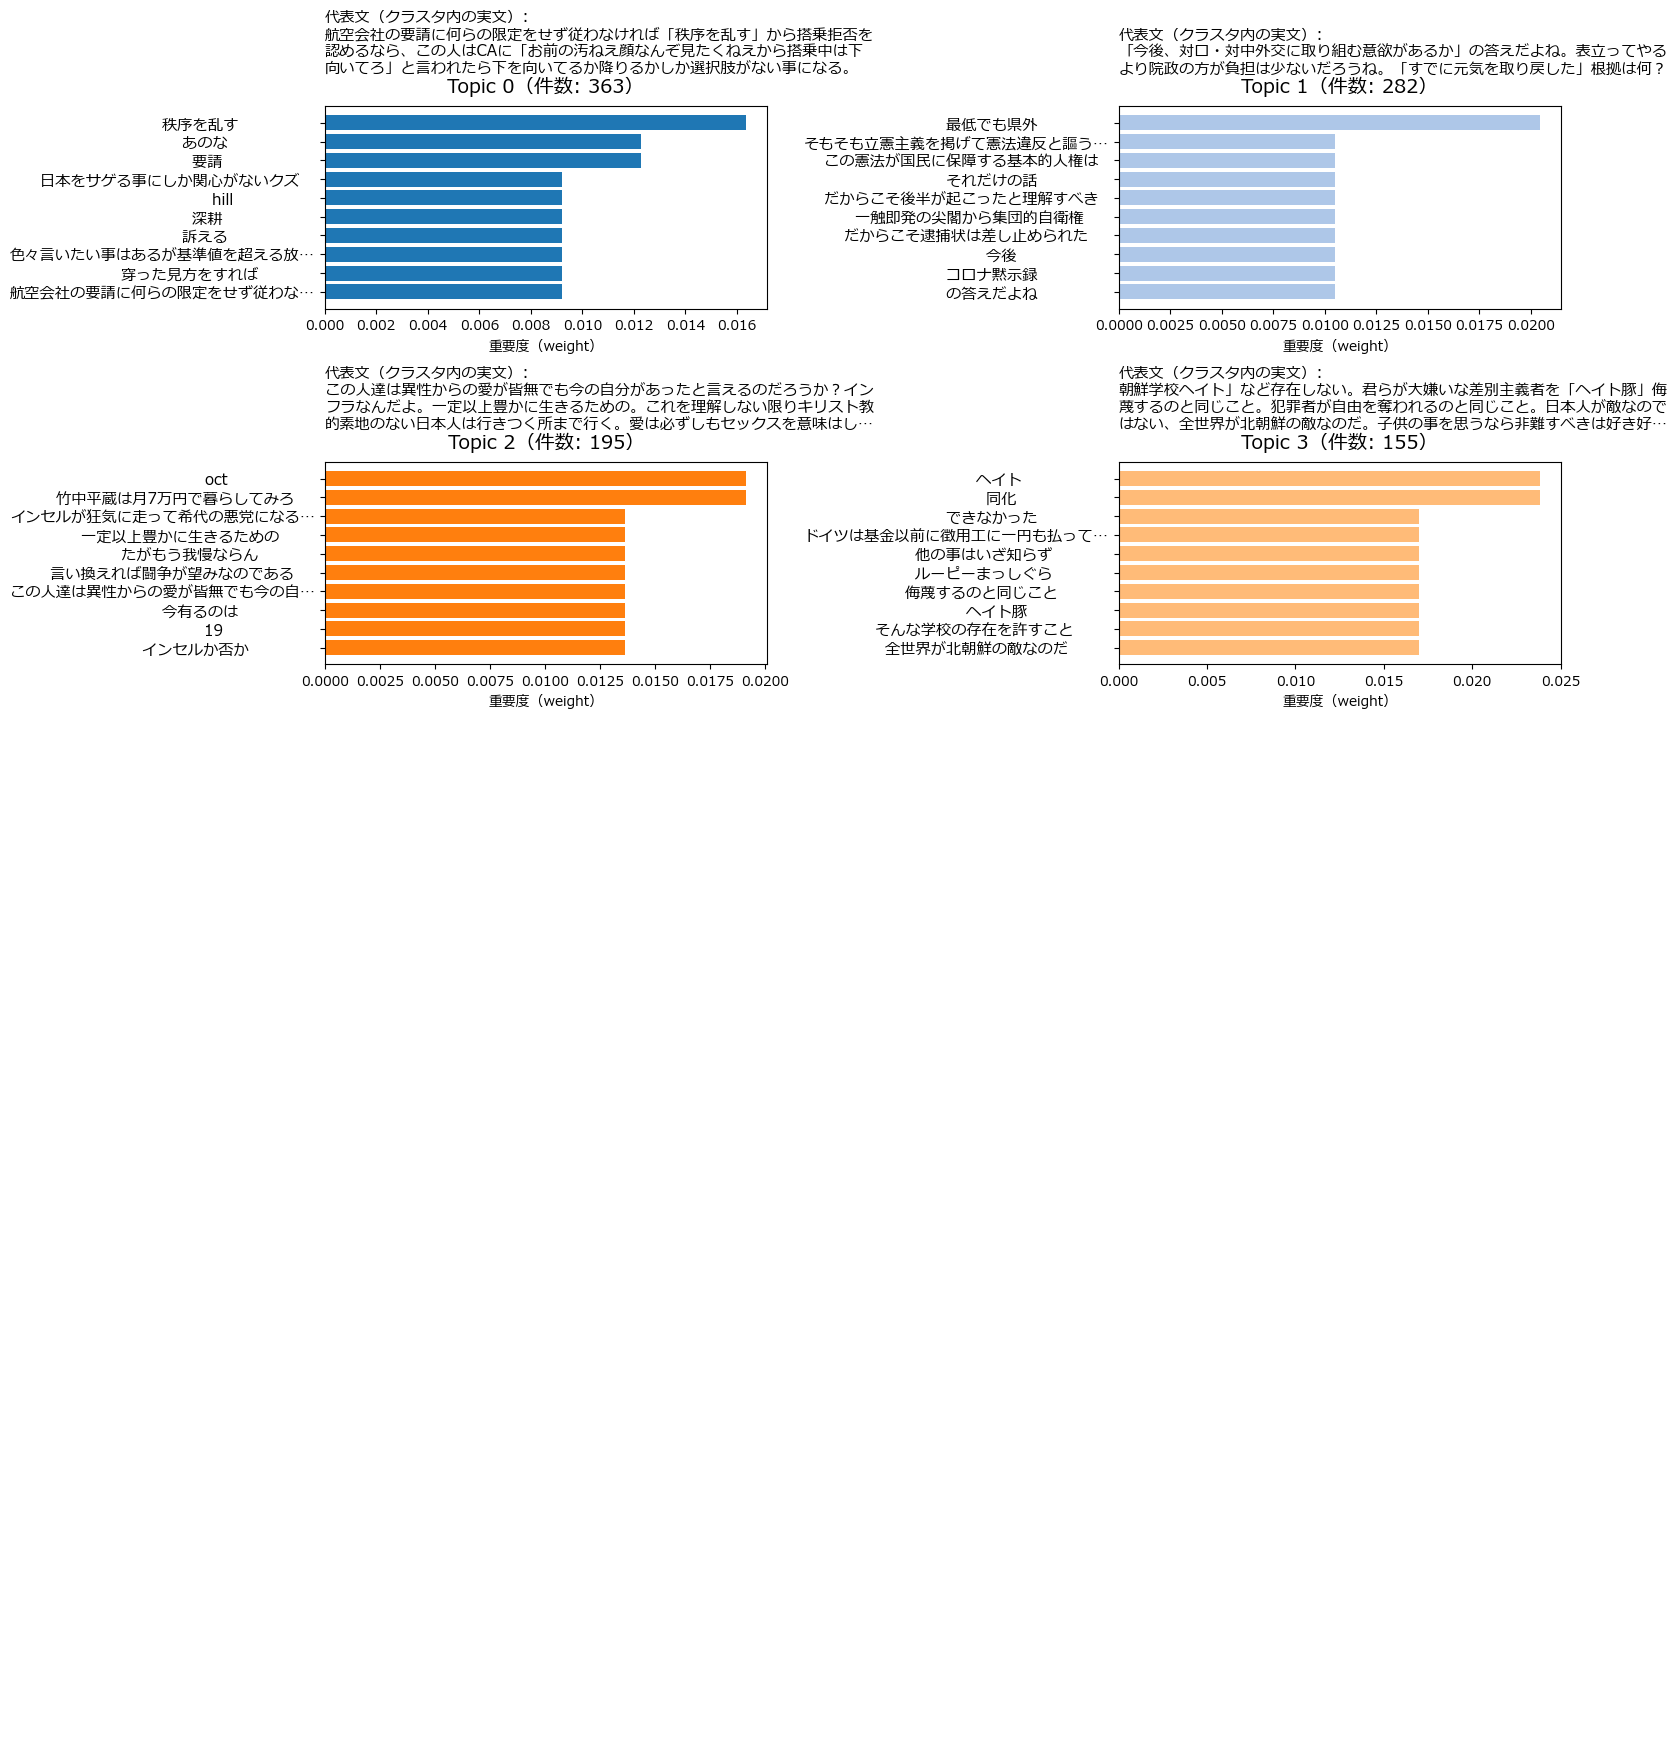

In [6]:
import math
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict

# ========== 設定（ここだけ調整） ==========
top_k = 10
n_words = 10
n_cols = 2

label_chars = 20          # 左ラベル（単語）揃え文字数
truncate_suffix = "…"

wrap_chars = 36           # ★代表文の折り返し幅（16〜26推奨）
max_lines  = 3            # ★代表文の最大行数
show_name  = False        # トピック名(Name)を表示したいなら True
hspace     = 0.9          # ★上下段の間隔（重なるなら増やす）
wspace     = 0.25         # 左右段の間隔
# =========================================

mpl.rcParams["font.family"] = "Meiryo"
mpl.rcParams["axes.unicode_minus"] = False

# ---- 上位トピック（-1除外） ----
topic_info = topic_model.get_topic_info()
top_topics_df = topic_info[topic_info["Topic"] != -1].head(top_k)
topic_ids = top_topics_df["Topic"].astype(int).tolist()

# ---- トピックごとの色 ----
cmap = plt.get_cmap("tab20")
color_map = {tid: cmap(i % 20) for i, tid in enumerate(topic_ids)}

# ---- 重要：クラスタ内の文を集める（fit_transformと同じ docs_small と topics を使う）----
cluster_docs = defaultdict(list)
for d, t in zip(docs_small, topics):
    if t != -1:
        cluster_docs[int(t)].append(d)

def fit_label(s: str, width: int, suffix: str = "…") -> str:
    s = (s or "").replace("\n", " ").strip()
    if len(s) > width:
        s = s[: max(width - len(suffix), 0)] + suffix
    return s.ljust(width)

def wrap_text(s: str, width: int, max_lines: int = None) -> str:
    """日本語でも確実に折り返すため、width文字ごとに手動改行"""
    s = str(s).replace("\n", " ").strip()
    if not s:
        return ""
    lines = [s[i:i+width] for i in range(0, len(s), width)]
    if max_lines is not None and len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1][:-1] + "…"
    return "\n".join(lines)

def pick_doc_from_cluster(tid: int, topn_words: int = 10) -> str:
    """
    代表語（上位topn_words）を多く含むクラスタ内文を1つ選ぶ。
    棒グラフ（代表語）と内容が対応しやすい。
    """
    docs = cluster_docs.get(tid, [])
    if not docs:
        return ""

    # 代表語（短い語が多いので部分一致でもOKだが、誤爆が気になるなら正規表現で厳密化も可）
    keywords = [w for w, _ in (topic_model.get_topic(tid) or [])[:topn_words]]

    best_score = -1
    best_doc = docs[0]

    for d in docs:
        score = sum(1 for w in keywords if w in d)
        # 同点のときは短めの文を優先（読みやすさ）
        if score > best_score or (score == best_score and len(d) < len(best_doc)):
            best_score = score
            best_doc = d

    return best_doc

# ---- 2段組の枠 ----
n_rows = math.ceil(top_k / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows), squeeze=False) # 4 * n_rowsは棒の太さ
axes = axes.flatten()

for ax, (_, row) in zip(axes, top_topics_df.iterrows()):
    tid = int(row["Topic"])
    count = int(row["Count"])
    name  = str(row["Name"])

    # ★ここが入れ替え点：代表文（クラスタに使った実文から選ぶ）
    rep_doc = pick_doc_from_cluster(tid, topn_words=10)
    rep_doc_wrapped = wrap_text(rep_doc, width=wrap_chars, max_lines=max_lines)

    # 代表語（棒グラフ）
    words = topic_model.get_topic(tid) or []
    dfw = pd.DataFrame(words[:n_words], columns=["word", "weight"]).sort_values("weight")
    dfw["word_fixed"] = dfw["word"].map(lambda x: fit_label(x, label_chars, truncate_suffix))

    ax.barh(dfw["word_fixed"], dfw["weight"], color=color_map[tid])
    ax.set_title(f"Topic {tid}（件数: {count}）", fontsize=14, pad=10)

    extra = ""
    if show_name:
        extra += "トピック名：" + wrap_text(name, width=wrap_chars, max_lines=1) + "\n"

    # ★代表文ブロック（末尾に空行を1つ入れて重なり防止）
    ax.text(
        0.0, 1.06,
        extra + "代表文（クラスタ内の実文）:\n" + rep_doc_wrapped + "\n",
        transform=ax.transAxes,
        va="bottom", ha="left",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="none"),
        clip_on=False
    )

    ax.set_xlabel("重要度（weight）")
    ax.tick_params(axis="y", labelsize=11)

# 余り枠を消す
for ax in axes[len(top_topics_df):]:
    ax.axis("off")

plt.subplots_adjust(hspace=hspace, wspace=wspace)
plt.tight_layout()
plt.show()
